Tag 3: Modelltraining, Evaluierung und Metriken


Übungsaufgaben (praktisch und freiwillig zu Tag 3)



Aufgabe 1: Splitte den Iris-Datensatz in Trainings- und Testdaten (es soll 20% Test- und 80 % Trainingsdatensätze sein)

Berechne Accuracy und F1-Score für ein beliebiges Klassifikationsmodell.


Gerne den Code verwenen und vervollständigen!


In [ ]:

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

# Iris-Daten laden
iris = load_iris()
X, y = iris.data, iris.target

# Datensatz aufteilen (80% Training, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Klassifikationsmodell wählen
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metriken berechnen
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro') 

print("Accuracy:", accuracy)
print("F1-Score:", f1)

Accuracy: 1.0
F1-Score: 1.0



Erklärung:

Wir benutzen hier den RandomForestClassifier.

Die Metriken werden mit average='weighted' berechnet, weil der Iris-Datensatz 3 Klassen hat.



Aufgabe 2: Führe eine 5-fold Cross-Validation mit einem RandomForestClassifier auf einem eigenen Dataset durch. Gib den Mittelwert der Accuracy an.


In [2]:

from sklearn.model_selection import cross_val_score

# 5-fold Cross-Validation
model = RandomForestClassifier(random_state=42)
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print("Cross-Validation Accuracies:", cv_scores)
print("Mittlere Accuracy:", cv_scores.mean())



Cross-Validation Accuracies: [0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
Mittlere Accuracy: 0.9666666666666668



Erklärung:

Das Modell wird 5-mal trainiert und getestet, jedes Mal auf einem anderen Teil des Datensatzes.

Die mittlere Accuracy gibt einen guten Schätzwert für die Modellgüte.



Aufgabe 3: Simuliere Overfitting: DecisionTree mit sehr kleiner und sehr großer Tiefe. Zeige, wie sich die Accuracy auf Trainings- und Testdaten unterscheidet.



Wie setzen Sie die Tiefe des Entscheidungsbaums ein?

Underfitting     max_depth = 
Overfitting      max_depth = 

In [ ]:

from sklearn.tree import DecisionTreeClassifier

# Modell mit sehr kleiner Tiefe (Underfitting)
tree_low = DecisionTreeClassifier(max_depth=2, random_state=42) # Baum darf nur 2 Ebenen tief gehen
tree_low.fit(X_train, y_train)
print("Kleine Tiefe:")
print("Train Accuracy:", accuracy_score(y_train, tree_low.predict(X_train)))
print("Test Accuracy:", accuracy_score(y_test, tree_low.predict(X_test)))

# Modell mit sehr großer Tiefe (Overfitting)
tree_high = DecisionTreeClassifier(max_depth=None, random_state=42) # Baum wächst komplett (bis perfekte Trennung)
tree_high.fit(X_train, y_train)
print("\nGroße Tiefe:")
print("Train Accuracy:", accuracy_score(y_train, tree_high.predict(X_train)))
print("Test Accuracy:", accuracy_score(y_test, tree_high.predict(X_test)))



Kleine Tiefe:
Train Accuracy: 0.95
Test Accuracy: 0.9666666666666667

Große Tiefe:
Train Accuracy: 1.0
Test Accuracy: 1.0



Erklärung:

Bei kleiner Tiefe wird das Modell zu einfach (Underfitting).

Bei großer Tiefe merkt sich der Baum alles (Overfitting) → Testgenauigkeit fällt ab.



Aufgabe 4: Precision und Recall bei stark unausgeglichenen Klassen. Warum ist Accuracy nicht aussagekräftig?


Führen Sie das Programm aus, was fällt Ihnen auf?


Warum ist die Accuracy immer so gut? 


In [ ]:

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score

# Unausgeglichene Daten simulieren
np.random.seed(42)
X_imbal = np.random.rand(200, 4)
y_imbal = np.concatenate([np.zeros(180), np.ones(20)])  # 180x Klasse 0, 20x Klasse 1 
# -> Das Modell kann einfach immer 0 sagen 

# Splitten
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_imbal, y_imbal, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train_i, y_train_i)
y_pred_i = model.predict(X_test_i)

# Metriken
accuracy_i = accuracy_score(y_test_i, y_pred_i) #Accuracy sieht gut aus, auch wenn Modell schlecht ist -> wertlos
precision_i = precision_score(y_test_i, y_pred_i)
recall_i = recall_score(y_test_i, y_pred_i) 

print("Accuracy:", accuracy_i)
print("Precision:", precision_i)
print("Recall:", recall_i)



Accuracy: 0.95
Precision: 0.0
Recall: 0.0


c:\ProgramData\anaconda3\envs\WBS_2026_tensor\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Erklärung:
1. Warum ist Accuracy nicht aussagekräftig? -> Accuracy misst „wie oft ich richtig rate“, aber nicht „ob ich die wichtigen Dinge richtig erkenne“.

2. Führen Sie das Programm aus, was fällt Ihnen auf?

3. Warum ist die Accuracy immer so gut? -> Accuracy ist oft gut (hoch), weil weil die Daten ungleich verteilt sind.


Aufgabe 5: Zeichne die ROC-Kurve für ein Klassifikationsmodell und ermittle den AUC-Wert.


Bitte Code ausführen!

Was sagt die Kurve aus?


Accuracy: 1.0
F1-Score: 1.0


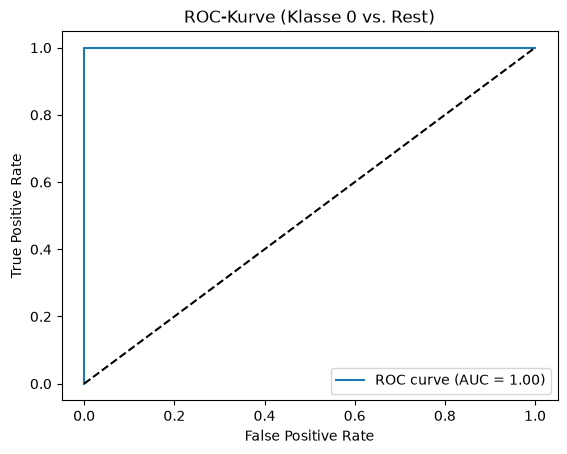

AUC: 1.0


In [ ]:

# Modell iris

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

# Iris-Daten laden
iris = load_iris()
X, y = iris.data, iris.target

# Datensatz aufteilen (80% Training, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Klassifikationsmodell wählen
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metriken berechnen
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')  # Mehrklassen!

print("Accuracy:", accuracy)
print("F1-Score:", f1)


# Auswerten mit der ROC Kurve


from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Wir nehmen das Modell aus Aufgabe 1, predict_proba() liefert keine Klassen, sondern Wahrscheinlichkeiten.
y_proba = model.predict_proba(X_test)[:, 1] if len(np.unique(y))==2 else model.predict_proba(X_test)[:, 0]  # Für Binary

# Für Iris (3 Klassen): Wir nehmen nur Klasse 0 als Beispiel (one-vs-rest)
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=[0,1,2])[:,0] 


fpr, tpr, thresholds = roc_curve(y_test_bin, y_proba) # thresholds: Die verschiedenen Entscheidungsschwellen, bei denen fpr und tpr berechnet werden
roc_auc = auc(fpr, tpr) # AUC: Die Fläche unter der ROC-Kurve wird berechnet.

plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-Kurve (Klasse 0 vs. Rest)')
plt.legend()
plt.show()

print("AUC:", roc_auc)



Erklärung:

AUC = 1.00 -> perfekte Trennung zwischen Klasse 0 und den restlichen Klassen

Das Modell erkennt alles korrekt: keine False Positives, keine False Negatives

Accuracy = 1.0, F-1 Score = 1.0 -> fehlerfreie Klassifikation